In [1]:
# ══════════════════════════════════════════════════════════════════
# NB02 — IR Financial Extraction
# The Platform Shift: A Deep Dive
# ══════════════════════════════════════════════════════════════════
#
# Extraction strategy:
#   Nintendo    → PDF pdfplumber
#   EA          → SEC EDGAR companyfacts XBRL API
#   Take-Two    → SEC EDGAR 10-K HTM (Net Bookings not in XBRL)
#   Sony        → PDF pdfplumber (G&NS segment not in XBRL)
#   Bandai Namco→ PDF pdfplumber (Digital segment not in XBRL)
#   Sega Sammy  → PDF pdfplumber (Entertainment Contents not in XBRL)
#   Square Enix → PDF pdfplumber (Digital Entertainment not in XBRL)
#   Ubisoft     → PDF pdfplumber (not SEC/EDINET filer)
#
# Inputs:  downloaded PDFs / HTMs / API responses
# Outputs: NB02_revenue_data.csv, NB02_revenue_pivot.csv,
#          NB02_revenue_overview.png
# ══════════════════════════════════════════════════════════════════

# ── CELL 1: Config ────────────────────────────────────────────────
USE_CACHE    = True
FISCAL_YEARS = [2022, 2023, 2024, 2025]  # March 31 FY end for JP; varies for Western

# API endpoints
EDGAR_CIK       = {'ea': '0000712515', 'take_two': '0000946581'}
EDGAR_FACTS_URL = 'https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json'

import sys
from pathlib import Path
EXTRACTORS_PATH = str(Path('../extractors').resolve())
if EXTRACTORS_PATH not in sys.path:
    sys.path.insert(0, EXTRACTORS_PATH)
if 'game_registry' in sys.modules:
    del sys.modules['game_registry']

print(f'USE_CACHE={USE_CACHE} | FY={FISCAL_YEARS}')
print(f'EDGAR CIKs  : {EDGAR_CIK}')


USE_CACHE=True | FY=[2022, 2023, 2024, 2025]
EDGAR CIKs  : {'ea': '0000712515', 'take_two': '0000946581'}


In [2]:
# ── CELL 2: Imports, Paths, Environment ──────────────────────────
import os
import re
import json
import time
import logging
import requests
import pdfplumber
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path
from io import BytesIO
from bs4 import BeautifulSoup

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
log = logging.getLogger(__name__)

# Paths
ROOT      = Path('..').resolve()
RAW_IR    = ROOT / 'data' / 'raw'    / 'ir'
PROCESSED = ROOT / 'data' / 'processed'
CACHE_IR  = ROOT / 'data' / 'cache'  / 'ir'
for d in [RAW_IR, PROCESSED, CACHE_IR]:
    d.mkdir(parents=True, exist_ok=True)

from dotenv import load_dotenv
load_dotenv(ROOT / '.env')

# JP font
jp_font = None
for fname in ['MS Gothic', 'Yu Gothic', 'Meiryo', 'IPAGothic']:
    try:
        matplotlib.font_manager.FontProperties(family=fname)
        jp_font = fname
        break
    except Exception:
        continue
if jp_font:
    plt.rcParams['font.family'] = jp_font

print(f'ROOT     : {ROOT}')
print(f'JP font  : {jp_font}')


ROOT     : C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive
JP font  : MS Gothic


In [3]:
# ── CELL 3: IR Registry ───────────────────────────────────────────
# PDF URLs: manually verified lookup dicts.
# IR sites change filename conventions each year — no derivable pattern.
# API-sourced companies (nintendo, ea) still have urls=None entries
# so the download cell skips them cleanly.

def make_urls(fy_list, lookup):
    return {fy: lookup.get(fy) for fy in fy_list}

IR_REGISTRY = {

    # ── Sony Group ────────────────────────────────────────────────
    # JP IR slides; G&NS segment table pages 4-11, 億円 → /10 → ¥B
    # Pattern: {2-digit FY}q4_sonypre.pdf — consistent since FY2019
    'sony': {
        'name':            'Sony Group Corporation',
        'segment':         'Game & Network Services',
        'segment_aliases': ['Game & Network Services', 'G&NS', 'Game and Network Services'],
        'currency':        'JPY',
        'fy_end':          'March',
        'source':          'pdf',
        'urls': make_urls(FISCAL_YEARS, {
            2022: 'https://www.sony.com/ja/SonyInfo/IR/library/presen/er/pdf/22q4_sonypre.pdf',
            2023: 'https://www.sony.com/ja/SonyInfo/IR/library/presen/er/pdf/23q4_sonypre.pdf',
            2024: 'https://www.sony.com/ja/SonyInfo/IR/library/presen/er/pdf/24q4_sonypre.pdf',
            2025: None,  # Not yet published as of Mar 2026; re-check May 2025
        }),
    },

    # ── Bandai Namco ──────────────────────────────────────────────
    # JP 決算短信; Digital segment (デジタル事業) external sales, ¥M → /1000
    # FY2022/2023: pdfplumber table. FY2024/2025: text regex fallback.
    'bandai_namco': {
        'name':            'Bandai Namco Holdings',
        'segment':         'Digital',
        'segment_aliases': ['Digital Business', 'Digital Segment', 'Digital'],
        'currency':        'JPY',
        'fy_end':          'March',
        'source':          'pdf',
        'url_base':        'https://www.bandainamco.co.jp/en/ir/library/financialstatements.html',
        'urls': make_urls(FISCAL_YEARS, {
            2022: 'https://www.bandainamco.co.jp/files/ir/financialstatements/pdf/20220511_Result.pdf',
            2023: 'https://www.bandainamco.co.jp/files/ir/financialstatements/pdf/20230510_Result.pdf',
            2024: 'https://www.bandainamco.co.jp/files/ir/financialstatements/pdf/20240509_Result.pdf',
            2025: 'https://www.bandainamco.co.jp/files/ir/financialstatements/pdf/20250508_Result.pdf',
        }),
    },

    # ── Sega Sammy ────────────────────────────────────────────────
    # EN IR presentation; Entertainment Contents segment already in ¥B
    # Three-number regex: [prior FY] [current FY] [forecast] → pick current
    'sega_sammy': {
        'name':            'Sega Sammy Holdings',
        'segment':         'Entertainment Contents',
        'segment_aliases': ['Entertainment Contents Business', 'Entertainment Contents'],
        'currency':        'JPY',
        'fy_end':          'March',
        'source':          'pdf',
        'url_base':        'https://www.segasammy.co.jp/en/ir/library/presentation/',
        'urls': make_urls(FISCAL_YEARS, {
            2022: 'https://www.segasammy.co.jp/cms/wp-content/uploads/pdf/en/ir/20220513_presentation_eng_final_1.pdf',
            2023: 'https://www.segasammy.co.jp/cms/wp-content/uploads/pdf/en/ir/20230428_q4_presentation_e_final.pdf',
            2024: 'https://www.segasammy.co.jp/cms/wp-content/uploads/pdf/en/ir/20240510_presentation_e.pdf',
            2025: 'https://www.segasammy.co.jp/cms/wp-content/uploads/pdf/en/ir/20250512_q4_presentation_e.pdf',
        }),
    },

    # ── Square Enix ───────────────────────────────────────────────
    # JP IR slides; デジタルエンタテインメント segment, 億円 → /10 → ¥B
    # Pattern: {2-digit FY}q4slidesJPN.pdf — consistent
    'square_enix': {
        'name':            'Square Enix Holdings',
        'segment':         'Digital Entertainment',
        'segment_aliases': ['Digital Entertainment', 'HD Games', 'MMO'],
        'currency':        'JPY',
        'fy_end':          'March',
        'source':          'pdf',
        'urls': make_urls(FISCAL_YEARS, {
            2022: 'https://www.hd.square-enix.com/jpn/ir/pdf/22q4slidesJPN.pdf',
            2023: 'https://www.hd.square-enix.com/jpn/ir/pdf/23q4slidesJPN.pdf',
            2024: 'https://www.hd.square-enix.com/jpn/ir/pdf/24q4slidesJPN.pdf',
            2025: 'https://www.hd.square-enix.com/jpn/ir/pdf/25q4slidesJPN.pdf',
        }),
    },

    # ── Nintendo ──────────────────────────────────────────────────
    # PDF 
    'nintendo': {
            'name':            'Nintendo Co., Ltd.',
            'segment':         'Total Net Sales',
            'segment_aliases': ['Net sales', 'Total net sales'],
            'currency':        'JPY',
            'fy_end':          'March',
            'source':          'pdf',
            'urls': make_urls(FISCAL_YEARS, {
                2022: 'https://www.nintendo.co.jp/ir/pdf/2022/220510e.pdf',
                2023: 'https://www.nintendo.co.jp/ir/pdf/2023/230509e.pdf',
                2024: 'https://www.nintendo.co.jp/ir/pdf/2024/240507e.pdf',
                2025: 'https://www.nintendo.co.jp/ir/pdf/2025/250508e.pdf',
            }),
        },
    # ── EA ────────────────────────────────────────────────────────
    # SOURCE: SEC EDGAR companyfacts XBRL API — CIK 0000712515
    # Concept: us-gaap:RevenueFromContractWithCustomerExcludingAssessedTax
    # Fallback: us-gaap:Revenues. Duration filter 340-400 days annual.
    # PDF fallback retained if API fails.
    'ea': {
        'name':            'Electronic Arts',
        'segment':         'Total Net Revenue',
        'segment_aliases': ['Total net revenue', 'Net revenue'],
        'currency':        'USD',
        'fy_end':          'March',
        'source':          'edgar',
        'edgar_cik':       '0000712515',
        'urls': make_urls(FISCAL_YEARS, {
            2022: 'https://s204.q4cdn.com/701424631/files/doc_financials/2022/q4/Q4-FY22-Earnings-Release-Final.pdf',
            2023: 'https://s204.q4cdn.com/701424631/files/doc_financials/2023/q4/Q4-FY23-Earnings-Release-Final.pdf',
            2024: 'https://s204.q4cdn.com/701424631/files/doc_financials/2024/q4/Q4-FY24-Earnings-Release-FINAL.pdf',
            2025: 'https://s204.q4cdn.com/701424631/files/doc_financials/2025/q4/Q4-FY25-Earnings-Press-Release-FINAL1.pdf',
        }),
    },

    # ── Take-Two ──────────────────────────────────────────────────
    # SOURCE: SEC EDGAR 10-K HTM parsed with BeautifulSoup.
    # Net Bookings is an operational metric — not in EDGAR XBRL taxonomy.
    # FY2022 reported in full dollars (÷1000); FY2023+ in millions.
    'take_two': {
        'name':            'Take-Two Interactive',
        'segment':         'Net Bookings',
        'segment_aliases': ['Net Bookings'],
        'currency':        'USD',
        'fy_end':          'March',
        'source':          'htm',
        'edgar_cik':       '0000946581',
        'urls': make_urls(FISCAL_YEARS, {
            2022: 'https://www.sec.gov/Archives/edgar/data/946581/000162828022014580/ttwo-20220331.htm',
            2023: 'https://www.sec.gov/Archives/edgar/data/946581/000162828023019851/ttwo-20230331.htm',
            2024: 'https://www.sec.gov/Archives/edgar/data/946581/000162828024024623/ttwo-20240331.htm',
            2025: 'https://www.sec.gov/Archives/edgar/data/946581/000162828025026694/ttwo-20250331.htm',
        }),
    },

    # ── Ubisoft ───────────────────────────────────────────────────
    # EN press release PDFs; net bookings €bn or table €M
    # Not an SEC/EDINET filer — no API option available
    'ubisoft': {
        'name':            'Ubisoft Entertainment',
        'segment':         'Net Bookings',
        'segment_aliases': ['Net bookings', 'Total net bookings'],
        'currency':        'EUR',
        'fy_end':          'March',
        'source':          'pdf',
        'urls': make_urls(FISCAL_YEARS, {
            2022: 'https://staticctf.akamaized.net/8aefmxkxpxwl/7FRH9Pjch7t9yXb4GMFgi0/db479fa1ae07fc5264f8b16e1d7a15f8/Ubisoft_FY22_Earnings_PR_English_Final.pdf',
            2023: 'https://staticctf.ubisoft.com/8aefmxkxpxwl/3HuZnFugstlcg9mb5TUTFn/d272d035c66d9c24c69b9985450943b7/Ubisoft_FY23_Earnings_PR_English_final.pdf',
            2024: 'https://staticctf.ubisoft.com/8aefmxkxpxwl/AwOkNohhzmR1qBmQ4Nj4h/096beaa470c05f39f77417742e4d25b8/Ubisoft_FY24_Earnings_PR_English_final.pdf',
            2025: 'https://staticctf.ubisoft.com/8aefmxkxpxwl/75aGUbWM9kwnQj44Tr7d6H/ce4ca047ddadf45cf1e98cea8d1d7a78/Ubisoft_FY25_PR_English_vfinal.pdf',
        }),
    },
}

# Validation summary
print(f'IR registry: {len(IR_REGISTRY)} companies × {len(FISCAL_YEARS)} fiscal years')
for k, v in IR_REGISTRY.items():
    n_urls = sum(1 for u in v['urls'].values() if u is not None)
    print(f'  {k:15s} | source={v["source"]:6s} | urls={n_urls}/{len(FISCAL_YEARS)} | {v["segment"]}')


IR registry: 8 companies × 4 fiscal years
  sony            | source=pdf    | urls=3/4 | Game & Network Services
  bandai_namco    | source=pdf    | urls=4/4 | Digital
  sega_sammy      | source=pdf    | urls=4/4 | Entertainment Contents
  square_enix     | source=pdf    | urls=4/4 | Digital Entertainment
  nintendo        | source=pdf    | urls=4/4 | Total Net Sales
  ea              | source=edgar  | urls=4/4 | Total Net Revenue
  take_two        | source=htm    | urls=4/4 | Net Bookings
  ubisoft         | source=pdf    | urls=4/4 | Net Bookings


In [4]:
# ── CELL 4: File Download (PDF + HTM only) ───────────────────────
# API-sourced companies (source='edgar') are skipped —
# their data is fetched programmatically in Cell 5.
# PDF/HTM files are cached to CACHE_IR with proper extensions.

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
    'Accept-Language': 'en-US,en;q=0.9,ja;q=0.8',
}

PDF_SOURCES = {'pdf', 'htm'}  # sources that need file download

def download_file(company_key, fy, url):
    """Download and cache a PDF or HTM file. Returns path or None."""
    file_type = IR_REGISTRY[company_key]['source']
    ext       = 'htm' if file_type == 'htm' else 'pdf'
    cache_path = CACHE_IR / f'{company_key}_{fy}.{ext}'

    if url is None:
        return None
    if USE_CACHE and cache_path.exists() and cache_path.stat().st_size > 0:
        log.info(f'[{company_key} FY{fy}] From cache ({cache_path.stat().st_size:,} bytes)')
        return cache_path
    try:
        log.info(f'[{company_key} FY{fy}] Downloading: {url}')
        r = requests.get(url, headers=HEADERS, timeout=30)
        r.raise_for_status()
        cache_path.write_bytes(r.content)
        log.info(f'[{company_key} FY{fy}] Saved {len(r.content):,} bytes → {cache_path.name}')
        time.sleep(1.5)  # polite crawl delay
        return cache_path
    except Exception as e:
        log.error(f'[{company_key} FY{fy}] FAILED: {e}')
        return None

# Download all PDF/HTM files; skip API-sourced companies
download_results = {}
for company_key, meta in IR_REGISTRY.items():
    if meta['source'] not in PDF_SOURCES:
        log.info(f'[{company_key}] Skipping download — source={meta["source"]} (API-fetched in Cell 5)')
        download_results[company_key] = {fy: None for fy in FISCAL_YEARS}
        continue
    download_results[company_key] = {}
    for fy, url in meta['urls'].items():
        download_results[company_key][fy] = download_file(company_key, fy, url)

# Summary
pdf_total   = sum(len(FISCAL_YEARS) for k in IR_REGISTRY if IR_REGISTRY[k]['source'] in PDF_SOURCES)
pdf_success = sum(1 for k, v in download_results.items()
                  for p in v.values() if p is not None)
print(f'\nDownload complete: {pdf_success}/{pdf_total} PDF/HTM files')
for company_key, years in download_results.items():
    source = IR_REGISTRY[company_key]['source']
    if source not in PDF_SOURCES:
        print(f'  {company_key:15s}: [API — fetched in Cell 5]')
        continue
    statuses = ' '.join(
        f'FY{fy}{"✓" if p else ("✗" if IR_REGISTRY[company_key]["urls"].get(fy) else "—")}'
        for fy, p in years.items()
    )
    print(f'  {company_key:15s}: {statuses}')


2026-03-29 08:38:46,691 [INFO] [sony FY2022] From cache (480,944 bytes)
2026-03-29 08:38:46,693 [INFO] [sony FY2023] From cache (553,353 bytes)
2026-03-29 08:38:46,697 [INFO] [sony FY2024] From cache (975,343 bytes)
2026-03-29 08:38:46,699 [INFO] [bandai_namco FY2022] From cache (1,039,883 bytes)
2026-03-29 08:38:46,702 [INFO] [bandai_namco FY2023] From cache (1,035,266 bytes)
2026-03-29 08:38:46,705 [INFO] [bandai_namco FY2024] From cache (1,022,833 bytes)
2026-03-29 08:38:46,709 [INFO] [bandai_namco FY2025] From cache (2,413,191 bytes)
2026-03-29 08:38:46,710 [INFO] [sega_sammy FY2022] From cache (3,494,529 bytes)
2026-03-29 08:38:46,713 [INFO] [sega_sammy FY2023] From cache (4,430,447 bytes)
2026-03-29 08:38:46,715 [INFO] [sega_sammy FY2024] From cache (9,282,906 bytes)
2026-03-29 08:38:46,716 [INFO] [sega_sammy FY2025] From cache (4,111,857 bytes)
2026-03-29 08:38:46,717 [INFO] [square_enix FY2022] From cache (1,533,599 bytes)
2026-03-29 08:38:46,719 [INFO] [square_enix FY2023] Fro


Download complete: 27/28 PDF/HTM files
  sony           : FY2022✓ FY2023✓ FY2024✓ FY2025—
  bandai_namco   : FY2022✓ FY2023✓ FY2024✓ FY2025✓
  sega_sammy     : FY2022✓ FY2023✓ FY2024✓ FY2025✓
  square_enix    : FY2022✓ FY2023✓ FY2024✓ FY2025✓
  nintendo       : FY2022✓ FY2023✓ FY2024✓ FY2025✓
  ea             : [API — fetched in Cell 5]
  take_two       : FY2022✓ FY2023✓ FY2024✓ FY2025✓
  ubisoft        : FY2022✓ FY2023✓ FY2024✓ FY2025✓


In [5]:
# ── CELL 5: Revenue Extraction ────────────────────────────────────
# Extraction hierarchy per company:
#   nintendo  → PDF
#   ea        → EDGAR XBRL API  → PDF fallback
#   take_two  → HTM BeautifulSoup
#   others    → pdfplumber (PDF)
#
# Partial cache: loads existing JSON, extracts only missing entries,
# saves back. Re-run is idempotent unless USE_CACHE=False.

CACHE_EXTRACTION = PROCESSED / 'NB02_extraction_cache.json'
PDF_MIN_BYTES    = 50_000

# ══ PDF helpers ═══════════════════════════════════════════════════

def is_real_pdf(pdf_path):
    if pdf_path is None:
        return False
    p = Path(pdf_path)
    if not p.exists():
        return False
    if p.stat().st_size < PDF_MIN_BYTES:
        log.warning(f'Skipping {p.name}: {p.stat().st_size:,} bytes (likely redirect)')
        return False
    with open(p, 'rb') as f:
        if not f.read(5).startswith(b'%PDF-'):
            log.warning(f'Skipping {p.name}: not a PDF')
            return False
    return True

def pdf_pages_text(pdf_path, max_pages=60):
    if not is_real_pdf(pdf_path):
        return []
    try:
        with pdfplumber.open(pdf_path) as pdf:
            return [p.extract_text() or '' for p in pdf.pages[:max_pages]]
    except Exception as e:
        log.warning(f'pdfplumber open failed {Path(pdf_path).name}: {e}')
        return []

def pdf_full_text(pdf_path, max_pages=60):
    return '\n'.join(pdf_pages_text(pdf_path, max_pages))

def clean_number(s):
    if s is None:
        return None
    s = str(s).strip()
    negative = s.startswith('(') and s.endswith(')')
    s = s.strip('()').replace(',','').replace('¥','').replace('$','').replace('€','').replace(' ','')
    try:
        v = float(s)
        return -v if negative else v
    except ValueError:
        return None

def is_plausible(v, min_val, max_val):
    """Reject year-like numbers (2009-2031) and out-of-range values."""
    if v is None:
        return False
    if 2009 < abs(v) < 2031:
        return False
    return min_val <= abs(v) <= max_val

def find_after_label(text, patterns, window=400, min_val=10, max_val=200_000):
    for pat in patterns:
        m = re.search(pat, text, re.IGNORECASE)
        if not m:
            continue
        snippet = text[m.end(): m.end() + window]
        for num_str in re.findall(r'-?\(?\d[\d,]*\.?\d*\)?', snippet):
            v = clean_number(num_str)
            if v is not None and is_plausible(v, min_val, max_val):
                return v
    return None

def find_after_label_anchor(text, anchor_patterns, label_patterns,
                            window=600, min_val=10, max_val=200_000):
    for anc in anchor_patterns:
        m = re.search(anc, text, re.IGNORECASE)
        if not m:
            continue
        section = text[m.start(): m.start() + window]
        v = find_after_label(section, label_patterns, window=window,
                             min_val=min_val, max_val=max_val)
        if v is not None:
            return v
    return None

def table_search(pdf_path, row_patterns, col_offset=1,
                 min_val=10, max_val=200_000, max_pages=60):
    if not is_real_pdf(pdf_path):
        return None
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages[:max_pages]:
                for table in (page.extract_tables() or []):
                    for row in table:
                        if not row:
                            continue
                        cells    = [str(c or '') for c in row]
                        row_text = ' '.join(cells)
                        for pat in row_patterns:
                            if re.search(pat, row_text, re.IGNORECASE):
                                for cell in cells[col_offset:]:
                                    v = clean_number(cell)
                                    if v is not None and is_plausible(v, min_val, max_val):
                                        return v
    except Exception as e:
        log.warning(f'table_search failed {Path(pdf_path).name}: {e}')
    return None

# ══ PDF extractors ════════════════════════════════════════════════

def extract_sony(pdf_path):
    """G&NS segment revenue ¥B from JP IR slides.
    Pages 4-11 table scan; ゲーム+売上 row; col3/col4 ≥25,000 億円 → /10."""
    def first_num(cell):
        s = str(cell or '').split('\n')[0].strip().replace(',', '')
        try:
            return float(s)
        except ValueError:
            return None
    if not is_real_pdf(pdf_path):
        return None
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages[4:12]:
                for table in (page.extract_tables() or []):
                    for row in table:
                        if not row:
                            continue
                        row_text = ' '.join(str(c or '') for c in row)
                        if 'ゲーム' not in row_text or '売上' not in row_text:
                            continue
                        cells = [str(c or '') for c in row]
                        v3 = first_num(cells[3]) if len(cells) > 3 else None
                        v4 = first_num(cells[4]) if len(cells) > 4 else None
                        for v in [v4, v3]:
                            if v and v >= 25_000:
                                return round(v / 10, 1)
    except Exception as e:
        log.warning(f'extract_sony failed: {e}')
    return None

def extract_bandai_namco(pdf_path):
    """Digital segment external customer sales ¥B.
    FY2022/2023: pdfplumber table; FY2024/2025: text regex.
    Values in ¥M → /1000. Expected: ~360–460 ¥B."""
    if not is_real_pdf(pdf_path):
        return None
    try:
        last_val = None
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                for table in (page.extract_tables() or []):
                    for i, row in enumerate(table):
                        if not row:
                            continue
                        row_text = ' '.join(str(c or '') for c in row)
                        if 'Apple' in row_text or 'Google' in row_text:
                            continue
                        if not any('デジタル' in str(c) and '事業' in str(c) for c in row):
                            continue
                        for srow in table[i+1:i+4]:
                            if not srow:
                                continue
                            stext = ' '.join(str(c or '') for c in srow)
                            if '売上高' not in stext and '外部顧客' not in stext:
                                continue
                            cell  = str(srow[1] or '')
                            first = cell.split('\n')[0].strip()
                            v     = clean_number(first)
                            if v and 100_000 < v < 1_000_000:
                                last_val = v
        if last_val:
            return round(last_val / 1000, 1)
        # Text fallback (FY2024/2025)
        text       = pdf_full_text(pdf_path)
        current_fy = re.search(
            r'当連結会計年度.{0,200}外部顧客への売上高\s+([\d,]+)',
            text, re.DOTALL
        )
        if current_fy:
            v = clean_number(current_fy.group(1))
            if v and 100_000 < v < 1_000_000:
                return round(v / 1000, 1)
        for m in re.finditer(r'外部顧客への売上高\s+([\d,]+)', text):
            v = clean_number(m.group(1))
            if v and 100_000 < v < 1_000_000:
                last_val = v
        return round(last_val / 1000, 1) if last_val else None
    except Exception as e:
        log.warning(f'extract_bandai_namco failed: {e}')
    return None

def extract_sega_sammy(pdf_path):
    """Entertainment Contents segment ¥B from EN IR slides.
    Three-number regex: [prior] [current] [forecast] — select current."""
    pages = pdf_pages_text(pdf_path)
    if not pages:
        return None
    full = '\n'.join(pages)
    m3   = re.search(r'Entertainment\s+Contents\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', full)
    m2   = re.search(r'Entertainment\s+Contents\s+([\d.]+)\s+([\d.]+)', full)
    if m3:
        has_forecast = bool(re.search(r'Forecast', full[m3.start()-300:m3.start()]))
        val = m3.group(2) if has_forecast else m3.group(3)
        return round(float(val), 1)
    elif m2:
        return round(float(m2.group(2)), 1)
    return None

def extract_square_enix(pdf_path):
    """Digital Entertainment segment ¥B from JP IR slides.
    Label search for デジタルエンタテインメント; 億円 → /10."""
    text = pdf_full_text(pdf_path)
    v    = find_after_label(text, [
        r'デジタルエンタテインメント',
        r'Digital\s+Entertainment',
    ], window=300, min_val=1000, max_val=10_000)
    if v is None:
        v = table_search(pdf_path, [
            r'デジタルエンタテインメント',
            r'Digital\s+Entertainment',
        ], col_offset=1, min_val=1000, max_val=10_000)
    return round(v / 10, 1) if v else None

def extract_nintendo_pdf(pdf_path, fy):
    """Nintendo total net sales ¥B from EN 決算短信 PDF.
    Page 0; 'Year ended March 31, {fy}' pattern; ≥500,000 ¥M → /1000."""
    if not is_real_pdf(pdf_path):
        return None
    try:
        with pdfplumber.open(pdf_path) as pdf:
            text = pdf.pages[0].extract_text() or ''
        for pattern in [
            rf'Year\s+ended\s+March\s+31,\s+{fy}\s+([\d,]+)\s+\([\d.]',
            rf'Year\s+ended\s+March\s+31,\s+{fy}\s+([\d,]+)\s+\d+\.\d',
        ]:
            for m in re.finditer(pattern, text):
                v = clean_number(m.group(1))
                if v and v >= 500_000:
                    return round(v / 1000, 1)
    except Exception as e:
        log.warning(f'extract_nintendo_pdf failed: {e}')
    return None

def extract_ea_pdf(pdf_path):
    """EA total net revenue $M from EN earnings PDF.
    Used as fallback when EDGAR API fails."""
    text = pdf_full_text(pdf_path)
    v    = find_after_label_anchor(
        text,
        anchor_patterns=[
            r'Fiscal\s+Year\s+Financial\s+Highlights',
            r'Full.Year\s+Financial\s+Highlights',
            r'Twelve\s+Months\s+Ended',
        ],
        label_patterns=[
            r'Total\s+net\s+revenue',
            r'Net\s+revenue',
        ],
        window=600, min_val=5000, max_val=15_000
    )
    return round(v, 0) if v else None

def extract_take_two(file_path):
    """Net Bookings $M from SEC EDGAR 10-K HTM (BeautifulSoup).
    FY2022: full dollars → ÷1000. FY2023+: already in millions."""
    if file_path is None or not Path(file_path).exists():
        return None
    try:
        html  = Path(file_path).read_text(encoding='utf-8', errors='ignore')
        soup  = BeautifulSoup(html, 'html.parser')
        for tag in soup.find_all(string=re.compile(r'Net\s+Bookings')):
            row = tag.find_parent('tr')
            if not row:
                continue
            cells    = [td.get_text(strip=True) for td in row.find_all(['td', 'th'])]
            row_text = ' '.join(cells)
            nums     = re.findall(r'\d[\d,]*\.?\d*', row_text)
            for n in nums:
                v = clean_number(n)
                if v is None:
                    continue
                if 1_000_000 < v < 10_000_000:   # FY2022 full dollars
                    return round(v / 1000, 0)
                if 1_000 < v < 10_000:            # FY2023+ millions
                    return round(v, 0)
    except Exception as e:
        log.warning(f'extract_take_two failed: {e}')
    return None

def extract_ubisoft(pdf_path):
    """Net bookings €M from EN press release PDF.
    Primary: regex €X.XXbn → ×1000.
    Fallback: pdfplumber table col0='Net bookings' → col1 value."""
    text = pdf_full_text(pdf_path)
    m    = re.search(r'Net\s+bookings[:\s]+[€]?([\d.]+)\s*bn', text, re.IGNORECASE)
    if m:
        return round(float(m.group(1)) * 1000, 1)
    if not is_real_pdf(pdf_path):
        return None
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages[:3]:
                for table in (page.extract_tables() or []):
                    for row in table:
                        if not row:
                            continue
                        col0 = str(row[0] or '')
                        if 'Net bookings' not in col0:
                            continue
                        col1       = str(row[1] or '')
                        col0_lines = col0.split('\n')
                        col1_lines = col1.split('\n')
                        for i, label in enumerate(col0_lines):
                            if 'Net bookings' in label and i < len(col1_lines):
                                v = clean_number(col1_lines[i])
                                if v and is_plausible(v, 500, 5000):
                                    return round(v, 1)
    except Exception as e:
        log.warning(f'extract_ubisoft table failed: {e}')
    v = find_after_label(text, [
        r'Net\s+bookings\s+for\s+(?:full.year|fiscal)',
        r'[Aa]nnual\s+net\s+bookings',
    ], window=150, min_val=500, max_val=5000)
    return round(v, 1) if v else None

# ══ EDGAR XBRL API extractor (EA) ═════════════════════════════════

def fetch_edgar_revenue(cik, fy, company_key='ea'):
    """Fetch annual revenue $M from SEC EDGAR companyfacts XBRL API.
    Tries concepts in order:
      1. us-gaap:RevenueFromContractWithCustomerExcludingAssessedTax
      2. us-gaap:Revenues
      3. us-gaap:SalesRevenueNet
    Duration filter: 340–400 days for annual filing.
    EA fiscal year ends March 31; matches end date 'YYYY-03-31'.
    """
    cache_path = CACHE_IR / f'{company_key}_edgar_{fy}.json'
    if USE_CACHE and cache_path.exists():
        log.info(f'[{company_key} FY{fy}] EDGAR from cache')
        with open(cache_path) as f:
            data = json.load(f)
        return data.get('value')

    concepts = [
        'RevenueFromContractWithCustomerExcludingAssessedTax',
        'Revenues',
        'SalesRevenueNet',
    ]
    cik_padded = cik.lstrip('0').zfill(10)
    url        = f'https://data.sec.gov/api/xbrl/companyfacts/CIK{cik_padded}.json'

    try:
        r = requests.get(url, headers={'User-Agent': 'StanZaen research@example.com'},
                         timeout=30)
        r.raise_for_status()
        facts = r.json()
        time.sleep(0.5)  # SEC rate limit courtesy

        us_gaap = facts.get('facts', {}).get('us-gaap', {})
        end_date = f'{fy}-03-31'  # EA FY ends March 31

        for concept in concepts:
            if concept not in us_gaap:
                continue
            units = us_gaap[concept].get('units', {})
            usd   = units.get('USD', [])
            for entry in usd:
                if entry.get('form') not in ('10-K', '10-K/A'):
                    continue
                if entry.get('end') != end_date:
                    continue
                # Duration filter: 340–400 days annual
                start = entry.get('start', '')
                if start:
                    try:
                        from datetime import date
                        d_start = date.fromisoformat(start)
                        d_end   = date.fromisoformat(entry['end'])
                        days    = (d_end - d_start).days
                        if not (340 <= days <= 400):
                            continue
                    except Exception:
                        pass
                val_usd = entry['val']
                # EDGAR values in dollars — convert to $M
                if val_usd > 1_000_000:
                    val_m = round(val_usd / 1_000_000, 0)
                else:
                    val_m = round(val_usd, 0)   # already in millions
                log.info(f'[{company_key} FY{fy}] EDGAR {concept}: ${val_m:,.0f}M')
                # Cache result
                with open(cache_path, 'w') as f:
                    json.dump({'concept': concept, 'value': val_m,
                               'end': end_date}, f)
                return val_m

        log.warning(f'[{company_key} FY{fy}] EDGAR: no matching annual entry found')
        return None

    except Exception as e:
        log.warning(f'[{company_key} FY{fy}] EDGAR fetch failed: {e}')
        return None

# ══ Dispatch table ════════════════════════════════════════════════

def extract_for(company_key, fy):
    """Route to correct extractor based on source field in IR_REGISTRY.
    API sources fall back to PDF if API returns None."""
    meta = IR_REGISTRY[company_key]

    if company_key == 'nintendo':
            pdf_path = download_results.get(company_key, {}).get(fy)
            return extract_nintendo_pdf(pdf_path, fy)

    elif company_key == 'ea':
        val = fetch_edgar_revenue(meta['edgar_cik'], fy, company_key)
        if val is not None:
            log.info(f'[ea FY{fy}] EDGAR → ${val:,.0f}M')
            return val
        log.warning(f'[ea FY{fy}] EDGAR returned None — trying PDF fallback')
        pdf_path = download_results.get(company_key, {}).get(fy)
        return extract_ea_pdf(pdf_path)

    elif company_key == 'take_two':
        return extract_take_two(download_results.get(company_key, {}).get(fy))

    elif company_key == 'sony':
        return extract_sony(download_results.get(company_key, {}).get(fy))

    elif company_key == 'bandai_namco':
        return extract_bandai_namco(download_results.get(company_key, {}).get(fy))

    elif company_key == 'sega_sammy':
        return extract_sega_sammy(download_results.get(company_key, {}).get(fy))

    elif company_key == 'square_enix':
        return extract_square_enix(download_results.get(company_key, {}).get(fy))

    elif company_key == 'ubisoft':
        return extract_ubisoft(download_results.get(company_key, {}).get(fy))

    return None

# ══ Partial cache execution ════════════════════════════════════════

if CACHE_EXTRACTION.exists():
    with open(CACHE_EXTRACTION) as f:
        raw = json.load(f)
    REVENUE_EXTRACTED = {
        company: {int(fy): val for fy, val in years.items()}
        for company, years in raw.items()
    }
else:
    REVENUE_EXTRACTED = {}

missing = {
    company_key: [
        fy for fy in FISCAL_YEARS
        if not (company_key in REVENUE_EXTRACTED
                and fy in REVENUE_EXTRACTED[company_key])
    ]
    for company_key in IR_REGISTRY
}
missing = {k: v for k, v in missing.items() if v}

extraction_log = []

if not missing:
    print('Cache complete — nothing to extract')
else:
    n_missing = sum(len(v) for v in missing.values())
    print(f'Extracting {n_missing} missing entries...')
    for company_key, fys in missing.items():
        REVENUE_EXTRACTED.setdefault(company_key, {})
        for fy in fys:
            # Skip if no source file and not API-sourced
            source    = IR_REGISTRY[company_key]['source']
            pdf_path  = download_results.get(company_key, {}).get(fy)
            no_source = (source in ('pdf', 'htm') and
                         (pdf_path is None or not Path(pdf_path).exists()))
            if no_source and source not in ('edinet', 'edgar'):
                REVENUE_EXTRACTED[company_key][fy] = None
                extraction_log.append((company_key, fy, None, 'NO_FILE'))
                continue
            try:
                val = extract_for(company_key, fy)
                REVENUE_EXTRACTED[company_key][fy] = val
                status = 'OK' if val is not None else 'PARSE_FAIL'
                extraction_log.append((company_key, fy, val, status))
            except Exception as e:
                REVENUE_EXTRACTED[company_key][fy] = None
                extraction_log.append((company_key, fy, None, f'ERROR: {e}'))

    with open(CACHE_EXTRACTION, 'w') as f:
        json.dump(REVENUE_EXTRACTED, f, indent=2)
    print(f'Cache updated: {CACHE_EXTRACTION}')

# ── Report ─────────────────────────────────────────────────────────
print('\n── Cell 5: Extraction Results ───────────────────────────────')
fail_count = 0
for company_key, years in REVENUE_EXTRACTED.items():
    meta   = IR_REGISTRY[company_key]
    source = meta['source'].upper()
    parts  = []
    for fy in sorted(years):
        val = years[fy]
        if val is not None:
            parts.append(f'FY{fy}: {val:,.1f}')
        else:
            parts.append(f'FY{fy}: ✗')
            fail_count += 1
    print(f'  {company_key:15s} [{source:6s}] ({meta["currency"]}): {" | ".join(parts)}')

no_file   = sum(1 for *_, s in extraction_log if s == 'NO_FILE')
no_pdf    = sum(1 for *_, s in extraction_log if s == 'NO_PDF')
real_fail = fail_count - no_file - no_pdf
total_ok  = len(IR_REGISTRY) * len(FISCAL_YEARS) - fail_count
print(f'\n  Coverage : {total_ok}/{len(IR_REGISTRY)*len(FISCAL_YEARS)}')
print(f'  NO_FILE  : {no_file} (URL not available yet)')
print(f'  FAILURES : {real_fail}')

if real_fail > 0:
    print('\n  ⚠ Parse failures:')
    for company_key, fy, val, status in extraction_log:
        if val is None and status == 'PARSE_FAIL':
            print(f'    {company_key} FY{fy}')


Cache complete — nothing to extract

── Cell 5: Extraction Results ───────────────────────────────
  sony            [PDF   ] (JPY): FY2022: 3,644.6 | FY2023: 4,267.7 | FY2024: 4,670.0 | FY2025: ✗
  bandai_namco    [PDF   ] (JPY): FY2022: 373.5 | FY2023: 381.1 | FY2024: 366.1 | FY2025: 450.1
  sega_sammy      [PDF   ] (JPY): FY2022: 235.9 | FY2023: 282.8 | FY2024: 318.0 | FY2025: 321.5
  square_enix     [PDF   ] (JPY): FY2022: 263.9 | FY2023: 279.6 | FY2024: 245.5 | FY2025: 248.1
  nintendo        [PDF   ] (JPY): FY2022: 1,695.3 | FY2023: 1,601.7 | FY2024: 1,671.9 | FY2025: 1,164.9
  ea              [EDGAR ] (USD): FY2022: 6,991.0 | FY2023: 7,426.0 | FY2024: 7,562.0 | FY2025: 7,463.0
  take_two        [HTM   ] (USD): FY2022: 3,408.0 | FY2023: 5,284.0 | FY2024: 5,333.0 | FY2025: 5,648.0
  ubisoft         [PDF   ] (EUR): FY2022: 2,128.5 | FY2023: 1,739.5 | FY2024: 2,321.4 | FY2025: 1,850.0

  Coverage : 31/32
  NO_FILE  : 0 (URL not available yet)
  FAILURES : 1

  ⚠ Parse failures:


In [6]:
# ── CELL 6: Validation ───────────────────────────────────────────
# Range check per publisher. YoY swing > 50% flagged with explanation.

EXPECTED_RANGES = {
    'sony':         (2000,  6000),   # ¥B
    'bandai_namco': ( 200,   600),   # ¥B
    'sega_sammy':   ( 100,   500),   # ¥B
    'square_enix':  ( 150,   400),   # ¥B
    'nintendo':     (1000,  2500),   # ¥B
    'ea':           (5000, 10000),   # $M
    'take_two':     (2000,  8000),   # $M
    'ubisoft':      (1000,  3000),   # €M
}

KNOWN_SWINGS = {
    ('take_two', 2023): 'Zynga acquisition May 2022',
    ('nintendo', 2025): 'Switch console cycle end',
}

print('── Cell 6: Validation ──────────────────────────────────────')
all_ok = True
for company_key, years in REVENUE_EXTRACTED.items():
    meta   = IR_REGISTRY[company_key]
    lo, hi = EXPECTED_RANGES[company_key]
    issues = []
    prev_val = None
    for fy in sorted(years):
        val = years[fy]
        if val is None:
            prev_val = None
            continue
        if not (lo <= val <= hi):
            issues.append(f'FY{fy} out of range: {val:,.1f} (expected {lo}–{hi})')
            all_ok = False
        if prev_val is not None:
            yoy = abs(val - prev_val) / prev_val * 100
            if yoy > 50:
                note = KNOWN_SWINGS.get((company_key, fy), 'check source')
                issues.append(f'FY{fy} swing {yoy:.0f}% YoY ({note})')
        prev_val = val
    status = '✓' if not issues else '⚠'
    vals_str = ' | '.join(
        f'FY{fy}: {v:,.1f}' if v is not None else f'FY{fy}: —'
        for fy, v in sorted(years.items())
    )
    print(f'  {status} {company_key:15s} ({meta["currency"]}): {vals_str}')
    for issue in issues:
        print(f'      → {issue}')

print(f'\n  {"All values plausible ✓" if all_ok else "⚠ Review flagged items above"}')


── Cell 6: Validation ──────────────────────────────────────
  ✓ sony            (JPY): FY2022: 3,644.6 | FY2023: 4,267.7 | FY2024: 4,670.0 | FY2025: —
  ✓ bandai_namco    (JPY): FY2022: 373.5 | FY2023: 381.1 | FY2024: 366.1 | FY2025: 450.1
  ✓ sega_sammy      (JPY): FY2022: 235.9 | FY2023: 282.8 | FY2024: 318.0 | FY2025: 321.5
  ✓ square_enix     (JPY): FY2022: 263.9 | FY2023: 279.6 | FY2024: 245.5 | FY2025: 248.1
  ✓ nintendo        (JPY): FY2022: 1,695.3 | FY2023: 1,601.7 | FY2024: 1,671.9 | FY2025: 1,164.9
  ✓ ea              (USD): FY2022: 6,991.0 | FY2023: 7,426.0 | FY2024: 7,562.0 | FY2025: 7,463.0
  ⚠ take_two        (USD): FY2022: 3,408.0 | FY2023: 5,284.0 | FY2024: 5,333.0 | FY2025: 5,648.0
      → FY2023 swing 55% YoY (Zynga acquisition May 2022)
  ✓ ubisoft         (EUR): FY2022: 2,128.5 | FY2023: 1,739.5 | FY2024: 2,321.4 | FY2025: 1,850.0

  All values plausible ✓


In [7]:
# ── CELL 7: Build Revenue DataFrame ──────────────────────────────
# Standardise all values to ¥B equivalent using approximate annual
# average FX rates (April–March FY window).
# FX source: Bank of Japan annual averages (approximate).

FX_TO_JPY = {
    'JPY': {2022: 1.0,   2023: 1.0,   2024: 1.0,   2025: 1.0  },
    'USD': {2022: 115.0, 2023: 132.0, 2024: 145.0, 2025: 152.0},
    'EUR': {2022: 130.0, 2023: 138.0, 2024: 158.0, 2025: 163.0},
}

rows = []
for company_key, years in REVENUE_EXTRACTED.items():
    meta     = IR_REGISTRY[company_key]
    currency = meta['currency']
    for fy, revenue in sorted(years.items()):
        if revenue is None:
            continue
        if currency == 'JPY':
            revenue_jpy_b = revenue
        else:
            fx            = FX_TO_JPY[currency][fy]
            revenue_jpy_b = round((revenue * fx) / 1000, 1)
        rows.append({
            'company':       company_key,
            'name':          meta['name'],
            'fy':            fy,
            'segment':       meta['segment'],
            'source':        meta['source'],
            'currency_orig': currency,
            'revenue_orig':  revenue,
            'revenue_jpy_b': revenue_jpy_b,
        })

revenue_df = pd.DataFrame(rows)
print(revenue_df.to_string(index=False))
print(f'\nShape: {revenue_df.shape}')


     company                   name   fy                 segment source currency_orig  revenue_orig  revenue_jpy_b
        sony Sony Group Corporation 2022 Game & Network Services    pdf           JPY        3644.6         3644.6
        sony Sony Group Corporation 2023 Game & Network Services    pdf           JPY        4267.7         4267.7
        sony Sony Group Corporation 2024 Game & Network Services    pdf           JPY        4670.0         4670.0
bandai_namco  Bandai Namco Holdings 2022                 Digital    pdf           JPY         373.5          373.5
bandai_namco  Bandai Namco Holdings 2023                 Digital    pdf           JPY         381.1          381.1
bandai_namco  Bandai Namco Holdings 2024                 Digital    pdf           JPY         366.1          366.1
bandai_namco  Bandai Namco Holdings 2025                 Digital    pdf           JPY         450.1          450.1
  sega_sammy    Sega Sammy Holdings 2022  Entertainment Contents    pdf         

In [8]:
# ── CELL 8: YoY Growth + CAGR ────────────────────────────────────

pivot = revenue_df.pivot(index='company', columns='fy', values='revenue_jpy_b')

# YoY
for yr_a, yr_b, col in [(2022,2023,'yoy_fy23'),(2023,2024,'yoy_fy24'),(2024,2025,'yoy_fy25')]:
    if yr_a in pivot.columns and yr_b in pivot.columns:
        pivot[col] = ((pivot[yr_b] - pivot[yr_a]) / pivot[yr_a] * 100).round(1)

# CAGR: longest available window
def cagr(row, start, end):
    if start not in row.index or end not in row.index:
        return None
    v_start, v_end = row[start], row[end]
    if pd.isna(v_start) or pd.isna(v_end) or v_start <= 0:
        return None
    n = end - start
    return round(((v_end / v_start) ** (1/n) - 1) * 100, 1)

pivot['cagr'] = pivot.apply(
    lambda r: cagr(r, 2022, 2025) or cagr(r, 2022, 2024), axis=1)

name_map   = {k: v['name'] for k, v in IR_REGISTRY.items()}
pivot['name'] = pivot.index.map(name_map)
pivot = pivot.sort_values(2024, ascending=False)

cols = (['name']
        + [y for y in [2022,2023,2024,2025] if y in pivot.columns]
        + [c for c in ['yoy_fy23','yoy_fy24','yoy_fy25','cagr'] if c in pivot.columns])
print('Revenue summary (¥B equivalent):')
print(pivot[cols].to_string())


Revenue summary (¥B equivalent):
fy                              name    2022    2023    2024    2025  yoy_fy23  yoy_fy24  yoy_fy25  cagr
company                                                                                                 
sony          Sony Group Corporation  3644.6  4267.7  4670.0     NaN      17.1       9.4       NaN  13.2
nintendo          Nintendo Co., Ltd.  1695.3  1601.7  1671.9  1164.9      -5.5       4.4     -30.3 -11.8
ea                   Electronic Arts   804.0   980.2  1096.5  1134.4      21.9      11.9       3.5  12.2
take_two        Take-Two Interactive   391.9   697.5   773.3   858.5      78.0      10.9      11.0  29.9
ubisoft        Ubisoft Entertainment   276.7   240.1   366.8   301.6     -13.2      52.8     -17.8   2.9
bandai_namco   Bandai Namco Holdings   373.5   381.1   366.1   450.1       2.0      -3.9      22.9   6.4
sega_sammy       Sega Sammy Holdings   235.9   282.8   318.0   321.5      19.9      12.4       1.1  10.9
square_enix     Square

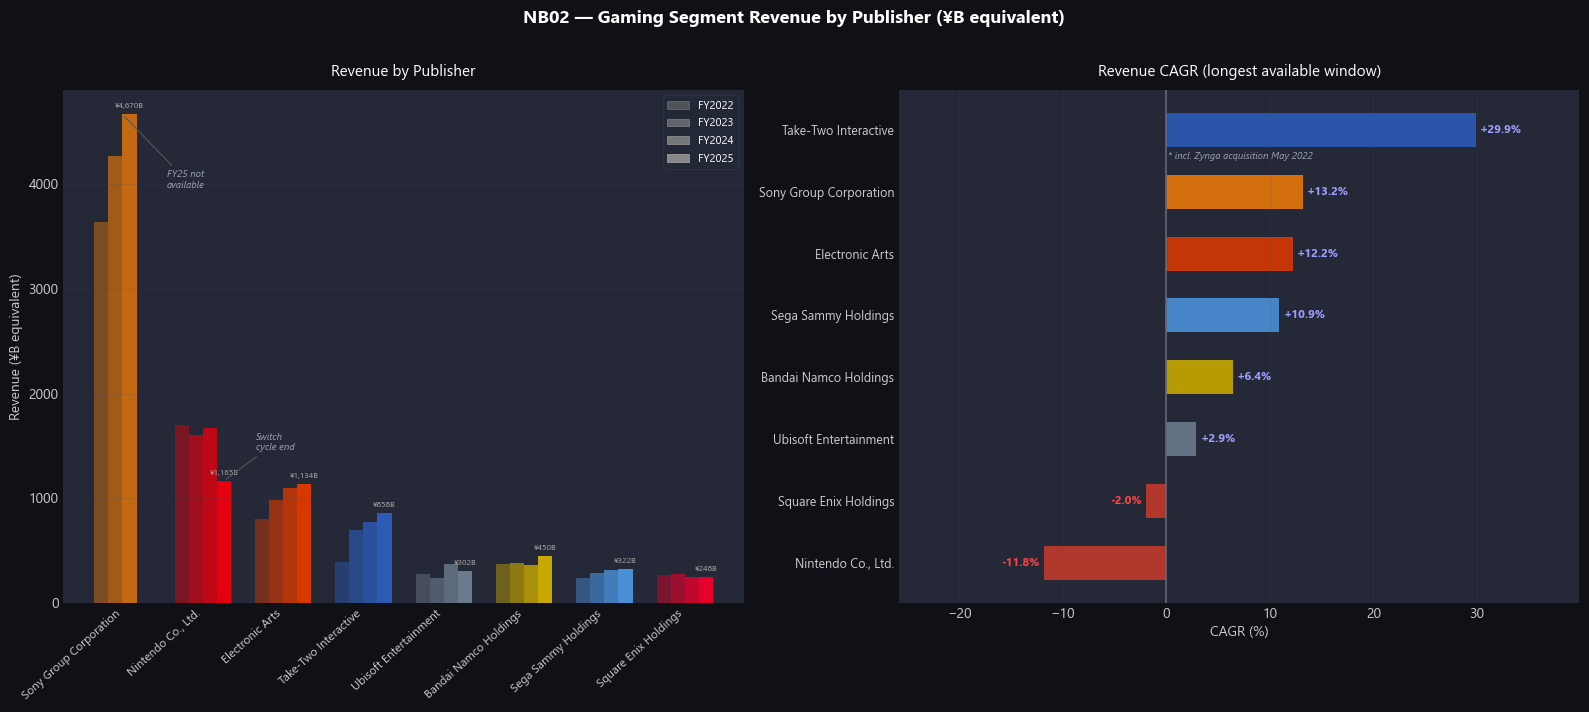

Saved: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\processed\NB02_revenue_overview.png


In [9]:
# ── CELL 9: Visualization ────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

PUBLISHER_COLORS = {
    'sony':         '#E8780A',
    'bandai_namco': '#C8A800',
    'sega_sammy':   '#4A90D9',
    'square_enix':  '#E4002B',
    'nintendo':     '#E4000F',
    'ea':           '#D63800',
    'take_two':     '#2B5BB5',
    'ubisoft':      '#6B7A8D',
}

plt.rcParams.update({
    'font.family':      'Segoe UI',
    'font.size':        10,
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#252836',
    'axes.edgecolor':   '#2D3148',
    'axes.labelcolor':  '#CCCCCC',
    'xtick.color':      '#CCCCCC',
    'ytick.color':      '#CCCCCC',
    'text.color':       '#FFFFFF',
    'grid.color':       '#2D3148',
    'legend.facecolor': '#1F2937',
    'legend.edgecolor': '#374151',
})

fys_available = [y for y in [2022, 2023, 2024, 2025] if y in pivot.columns]
n_fys         = len(fys_available)
companies     = pivot.index.tolist()
labels        = [pivot.loc[c, 'name'] for c in companies]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0F1117')
fig.suptitle(
    'NB02 — Gaming Segment Revenue by Publisher (¥B equivalent)',
    fontsize=13, fontweight='bold', color='white', y=1.01
)

# ── Panel 1: Revenue bars (linear) ───────────────────────────────
ax = axes[0]
ax.set_facecolor('#252836')
w = 0.7 / n_fys
x = np.arange(len(companies))

for i, fy in enumerate(fys_available):
    offset     = (i - n_fys / 2 + 0.5) * w
    vals       = [
        pivot.loc[c, fy] if fy in pivot.columns and not pd.isna(pivot.loc[c, fy]) else 0
        for c in companies
    ]
    alpha      = 0.45 + 0.55 * (i / (n_fys - 1)) if n_fys > 1 else 1.0
    bar_colors = [PUBLISHER_COLORS.get(c, '#555555') for c in companies]
    ax.bar(x + offset, vals, width=w, color=bar_colors, alpha=alpha,
           label=f'FY{fy}', edgecolor='none')

# Value labels — latest available FY per company, horizontal
ax.set_ylim(bottom=0)
for ci, company in enumerate(companies):
    latest_val = None
    for fy in reversed(fys_available):
        if fy in pivot.columns and not pd.isna(pivot.loc[company, fy]):
            v = pivot.loc[company, fy]
            if v > 0:
                latest_val = (fy, v)
                break
    if latest_val is None:
        continue
    fy_used, val = latest_val
    fy_i         = fys_available.index(fy_used)
    offset       = (fy_i - n_fys / 2 + 0.5) * w
    ax.text(
        ci + offset,
        val + ax.get_ylim()[1] * 0.008,
        f'¥{val:,.0f}B',
        ha='center', va='bottom',
        fontsize=6, color='#AAAAAA', rotation=0,
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=42, ha='right', fontsize=8.5, color='#CCCCCC')
ax.set_ylabel('Revenue (¥B equivalent)', color='#CCCCCC')
ax.set_title('Revenue by Publisher', color='white', fontsize=11, pad=10)
ax.grid(axis='y', alpha=0.15, color='#4A5068')
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.tick_params(axis='both', length=0)

# FY legend with opacity gradient
fy_handles = [
    mpatches.Patch(
        facecolor='#888888',
        alpha=0.45 + 0.55 * (i / (n_fys - 1)) if n_fys > 1 else 1.0,
        label=f'FY{fy}',
        edgecolor='#AAAAAA', linewidth=0.5,
    )
    for i, fy in enumerate(fys_available)
]
ax.legend(handles=fy_handles, loc='upper right', fontsize=8,
          labelcolor='white', framealpha=0.4)

# Sony FY2025 annotation
if 'sony' in companies:
    sony_x = companies.index('sony')
    sony_y = pivot.loc['sony', 2024] if not pd.isna(pivot.loc['sony', 2024]) else 0
    ax.annotate(
        'FY25 not\navailable',
        xy=(sony_x, sony_y),
        xytext=(sony_x + 0.55, sony_y * 0.85),
        fontsize=7, color='#9CA3AF', style='italic',
        arrowprops=dict(arrowstyle='-', color='#555555', lw=0.8)
    )

# Nintendo Switch cycle annotation
if 'nintendo' in companies and 2025 in pivot.columns:
    nin_x   = companies.index('nintendo')
    nin_y25 = pivot.loc['nintendo', 2025]
    if not pd.isna(nin_y25):
        offset_last = ((n_fys - 1) - n_fys / 2 + 0.5) * w
        ax.annotate(
            'Switch\ncycle end',
            xy=(nin_x + offset_last, nin_y25),
            xytext=(nin_x + offset_last + 0.4, nin_y25 + ax.get_ylim()[1] * 0.06),
            fontsize=7, color='#9CA3AF', style='italic',
            arrowprops=dict(arrowstyle='-', color='#555555', lw=0.8)
        )

# ── Panel 2: CAGR horizontal bars ────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#252836')

cagr_sorted  = pivot['cagr'].dropna().sort_values(ascending=True)
cagr_labels  = [pivot.loc[c, 'name'] for c in cagr_sorted.index]
cagr_colors  = [
    PUBLISHER_COLORS.get(c, '#555555') if v >= 0 else '#C0392B'
    for c, v in zip(cagr_sorted.index, cagr_sorted.values)
]

bars = ax2.barh(cagr_labels, cagr_sorted.values,
                color=cagr_colors, alpha=0.9, edgecolor='none', height=0.55)

for bar, val in zip(bars, cagr_sorted.values):
    x_pos      = bar.get_width() + (0.4 if val >= 0 else -0.4)
    ha         = 'left' if val >= 0 else 'right'
    font_color = '#9E9EFF' if val >= 0 else '#FF4444'
    ax2.text(x_pos, bar.get_y() + bar.get_height() / 2,
             f'{val:+.1f}%', va='center', ha=ha,
             fontsize=8.5, color=font_color, fontweight='bold')

# Zynga note
if 'take_two' in cagr_sorted.index:
    tt_pos = list(cagr_sorted.index).index('take_two')
    ax2.text(
        cagr_sorted.min() + 12, tt_pos - 0.42,
        '* incl. Zynga acquisition May 2022',
        va='center', ha='left', fontsize=7, color='#9CA3AF', style='italic'
    )

ax2.axvline(0, color='#666677', linewidth=1.2, zorder=5)
ax2.set_xlim(cagr_sorted.min() - 14, cagr_sorted.max() + 10)
ax2.set_xlabel('CAGR (%)', color='#CCCCCC')
ax2.set_title('Revenue CAGR (longest available window)',
              color='white', fontsize=11, pad=10)
ax2.grid(axis='x', alpha=0.15, color='#4A5068')
ax2.spines[['top','right','left','bottom']].set_visible(False)
ax2.tick_params(axis='both', length=0)
ax2.set_yticks(range(len(cagr_labels)))
ax2.set_yticklabels(cagr_labels, color='#CCCCCC', fontsize=9)

plt.tight_layout()
out_path = PROCESSED / 'NB02_revenue_overview.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f'Saved: {out_path}')


In [10]:
# ── CELL 10: Save Outputs ─────────────────────────────────────────
out_csv   = PROCESSED / 'NB02_revenue_data.csv'
out_pivot = PROCESSED / 'NB02_revenue_pivot.csv'

revenue_df.to_csv(out_csv, index=False)
pivot.to_csv(out_pivot)

print(f'Saved: {out_csv}')
print(f'Saved: {out_pivot}')


Saved: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\processed\NB02_revenue_data.csv
Saved: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\processed\NB02_revenue_pivot.csv


In [11]:
# ── CELL 11: NB02 Observation ────────────────────────────────────
fy25_available = revenue_df[revenue_df['fy'] == 2025]['company'].tolist()
top_fy24_co    = pivot[2024].idxmax() if 2024 in pivot.columns else None
top_fy24_rev   = pivot.loc[top_fy24_co, 2024] if top_fy24_co else None
top_fy24_name  = pivot.loc[top_fy24_co, 'name'] if top_fy24_co else 'N/A'
fastest_co     = pivot['cagr'].idxmax()
fastest_name   = pivot.loc[fastest_co, 'name']
fastest_val    = pivot.loc[fastest_co, 'cagr']
declining      = pivot[pivot['cagr'] < 0]['name'].tolist()

source_map = {k: v['source'].upper() for k, v in IR_REGISTRY.items()}

print(f"""
NB02 Observation
─────────────────────────────────────────────────────
Publishers extracted : {len(revenue_df['company'].unique())}
Fiscal years         : FY2022–FY2025 (March 31 FY end for JP companies)
Currency             : Standardised to ¥B equivalent

Extraction sources
  Nintendo            : PDF
  EA                  : SEC EDGAR companyfacts XBRL API → PDF fallback
  Take-Two            : SEC EDGAR 10-K HTM (Net Bookings not in XBRL)
  Sony/BN/Sega/SE/Ubi : pdfplumber PDF (segment data not in XBRL)

FX assumptions       : USD/JPY {{2022:115, 2023:132, 2024:145, 2025:152}}
                       EUR/JPY {{2022:130, 2023:138, 2024:158, 2025:163}}

FY2025 coverage      : {len(fy25_available)}/8 publishers
                       Missing: Sony (not yet published as of {pd.Timestamp.today().strftime('%Y-%m-%d')})

Largest FY2024 (¥B)  : {top_fy24_name} (¥{top_fy24_rev:,.1f}B)
Fastest CAGR         : {fastest_name} ({fastest_val:+.1f}%)
Declining CAGR       : {', '.join(declining) if declining else 'None'}

Key notes
  Take-Two FY23  : +55% YoY = Zynga acquisition (May 2022), not organic
  Nintendo FY25  : -30% YoY = Switch console cycle end
  Segment defs   : vary by publisher — see IR_REGISTRY for details

Next: NB03 — Publisher & Platform Analysis
""")



NB02 Observation
─────────────────────────────────────────────────────
Publishers extracted : 8
Fiscal years         : FY2022–FY2025 (March 31 FY end for JP companies)
Currency             : Standardised to ¥B equivalent

Extraction sources
  Nintendo            : PDF
  EA                  : SEC EDGAR companyfacts XBRL API → PDF fallback
  Take-Two            : SEC EDGAR 10-K HTM (Net Bookings not in XBRL)
  Sony/BN/Sega/SE/Ubi : pdfplumber PDF (segment data not in XBRL)

FX assumptions       : USD/JPY {2022:115, 2023:132, 2024:145, 2025:152}
                       EUR/JPY {2022:130, 2023:138, 2024:158, 2025:163}

FY2025 coverage      : 7/8 publishers
                       Missing: Sony (not yet published as of 2026-03-29)

Largest FY2024 (¥B)  : Sony Group Corporation (¥4,670.0B)
Fastest CAGR         : Take-Two Interactive (+29.9%)
Declining CAGR       : Nintendo Co., Ltd., Square Enix Holdings

Key notes
  Take-Two FY23  : +55% YoY = Zynga acquisition (May 2022), not organic
  Nint